In [252]:
source("/home/user/data2/lit/bin/lit_utils.R")
source("/home/user/data3/lit/project/sORFs/sORFs.utils.R")
lib_text()
lib_plot()

In [253]:
fread_c("../../processed/seve_list_compare/canonical_orfs.txt") -> canonical_orfs
fread_c("../../processed/seve_list_compare/denovo_orfs.txt") -> denovo_orfs
fread_c("../../processed/seve_list_compare/lnc_orfs.txt") -> lnc_orfs
colnames(canonical_orfs)
colnames(denovo_orfs)
nrow(denovo_orfs)
colnames(lnc_orfs)

[1] "ORF_id"                        "Isoform_id"                   
 [3] "Chr"                           "Strand"                       
 [5] "ORF_type"                      "Start_codon"                  
 [7] "Is_uniprot"                    "Is_canonical"                 
 [9] "ORF_length"                    "ORF_seq"                      
[11] "Isoform_structural_category"   "Isoform_subcategory"          
[13] "Geneid"                        "Gene_type"                    
[15] "RPF_reads"                     "Psites_number"                
[17] "RPF_RPKM"                      "Psites_RPKM"                  
[19] "RPF_codon_coverage"            "Psites_codon_coverage"        
[21] "FL"                            "FL_TPM"                       
[23] "N"                             "C"                            
[25] "A"                             "ORF_start"                    
[27] "ORF_end"                       "CDS_seq"                      
[29] "ORF_id_custom"                 "Is_PRICE"                     
[31] "Is_RiboCode"                   "Is_RibORF"                    
[33] "CDS_nt_len"                    "n_codons"                     
[35] "frame0"                        "frame1"                       
[37] "frame2"                        "total_psites"                 
[39] "frame0_fraction"               "frame0_codon_covered"         
[41] "Is_identified_by_over_1_tools" "Is_identified_by_over_2_tools"
[43] "Is_Ribo_ORF_custom"

[1] "ORF_id"                        "Isoform_id"                   
 [3] "Chr"                           "Strand"                       
 [5] "ORF_type"                      "Start_codon"                  
 [7] "Is_uniprot"                    "Is_canonical"                 
 [9] "ORF_length"                    "ORF_seq"                      
[11] "Isoform_structural_category"   "Isoform_subcategory"          
[13] "Geneid"                        "Gene_type"                    
[15] "RPF_reads"                     "Psites_number"                
[17] "RPF_RPKM"                      "Psites_RPKM"                  
[19] "RPF_codon_coverage"            "Psites_codon_coverage"        
[21] "FL"                            "FL_TPM"                       
[23] "N"                             "C"                            
[25] "A"                             "ORF_start"                    
[27] "ORF_end"                       "CDS_seq"                      
[29] "ORF_id_custom"                 "Is_PRICE"                     
[31] "Is_RiboCode"                   "Is_RibORF"                    
[33] "CDS_nt_len"                    "n_codons"                     
[35] "frame0"                        "frame1"                       
[37] "frame2"                        "total_psites"                 
[39] "frame0_fraction"               "frame0_codon_covered"         
[41] "MS_evidence_level_1"           "MS_evidence_level_2"          
[43] "MS_evidence_level_3"           "ev_age"                       
[45] "syn_age"                       "denovo"                       
[47] "lineage"                       "loc_times_blat"               
[49] "gene_times_blastn"             "gene_times_blastn_pc"         
[51] "Outgroup Homolog"              "lineage_n"                    
[53] "Outgroup Homolog n"            "Is_identified_by_over_1_tools"
[55] "Is_identified_by_over_2_tools" "Is_Ribo_ORF_custom"

[1] 7216

[1] "ORF_id"                        "Isoform_id"                   
 [3] "Chr"                           "Strand"                       
 [5] "ORF_type"                      "Start_codon"                  
 [7] "Is_uniprot"                    "Is_canonical"                 
 [9] "ORF_length"                    "ORF_seq"                      
[11] "Isoform_structural_category"   "Isoform_subcategory"          
[13] "Geneid"                        "Gene_type"                    
[15] "RPF_reads"                     "Psites_number"                
[17] "RPF_RPKM"                      "Psites_RPKM"                  
[19] "RPF_codon_coverage"            "Psites_codon_coverage"        
[21] "FL"                            "FL_TPM"                       
[23] "N"                             "C"                            
[25] "A"                             "ORF_start"                    
[27] "ORF_end"                       "CDS_seq"                      
[29] "ORF_id_custom"                 "Is_PRICE"                     
[31] "Is_RiboCode"                   "Is_RibORF"                    
[33] "CDS_nt_len"                    "n_codons"                     
[35] "frame0"                        "frame1"                       
[37] "frame2"                        "total_psites"                 
[39] "frame0_fraction"               "frame0_codon_covered"         
[41] "Is_identified_by_over_1_tools" "Is_identified_by_over_2_tools"
[43] "Is_Ribo_ORF_custom"

In [254]:
table(denovo_orfs$ORF_type)


     dORF      iORF noncoding     odORF     ouORF      uORF 
     2015       144      3311        55       213      1478 

In [255]:
canonical_orfs$Type_1 <- "Canonical"
denovo_orfs$Type_1 <- "De novo"
lnc_orfs$Type_1 <- "lncRNA"
canonical_orfs$lineage <- "NA"
lnc_orfs$lineage <- "NA"

In [256]:
colnames(canonical_orfs) -> cols
c(cols,"lineage") -> cols_1

In [257]:
rbind(canonical_orfs[,cols_1],denovo_orfs[,cols_1],lnc_orfs[,cols_1]) -> all
nrow(all)
table(all$lineage)

[1] 14142


boreoeutheria    catarrhini      hominoid         human        mammal 
          637          1630          1276           859           253 
           NA   placentalia      primates primatomorpha   simiiformes 
         6926           821           214            47          1479 

In [259]:
all <- all %>%
    mutate(Type_2 = case_when(
        Type_1=="Canonical"|Type_1=="lncRNA" ~ Type_1,
         Type_1=="De novo" ~ lineage
    ))
table(all$Type_2)


boreoeutheria     Canonical    catarrhini      hominoid         human 
          637          4506          1630          1276           859 
       lncRNA        mammal   placentalia      primates primatomorpha 
         2420           253           821           214            47 
  simiiformes 
         1479 

In [272]:
all <- all %>%
    mutate(Type_3 = case_when(
        Type_1=="Canonical"|Type_1=="lncRNA" ~ Type_1,
         lineage=="humman" | lineage=="hominoid" ~ "De novo human/hominoid genes",
        TRUE ~ "other"
    ))
table(all$Type_3)



                   Canonical De novo human/hominoid genes 
                        4506                         1276 
                      lncRNA                        other 
                        2420                         5940 

In [274]:
LEVELS <- c("human","hominoid","catarrhini","simiiformes","primates","primatomorpha","boreoeutheria",
            "placentalia","mammal","Canonical","lncRNA")
all$Type_3 <- factor(all$Type_3,levels=c("De novo human/hominoid genes","Canonical","lncRNA","other"))
all$Type_2 <- factor(all$Type_2,levels=LEVELS)
all$Type_1 <- factor(all$Type_1,levels=c("De novo","Canonical","lncRNA" ))

In [275]:
head(all,1)

,ORF_id,Isoform_id,Chr,Strand,ORF_type,Start_codon,Is_uniprot,Is_canonical,ORF_length,ORF_seq,⋯,frame0_codon_covered,Is_identified_by_over_1_tools,Is_identified_by_over_2_tools,Is_Ribo_ORF_custom,Type_1,lineage,lineage.1,Type_3,Type_2,GC_content
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<int>,<chr>,⋯,<int>,<lgl>,<lgl>,<lgl>,<fct>,<chr>,<chr>,<fct>,<fct>,<dbl>
1,PB.1001.14:chr1:-|8|2605:155:404|canonical|ATG,PB.1001.14,chr1,-,canonical,ATG,FALSE,TRUE,82,MDDWKPSPLIKPFGARKKRSWYLTWKYKLTNQRALRRFCQTGAVLFLLVTVIVNIKLILDTRRAISEANEDPEPEQDYGAGG,⋯,31,TRUE,TRUE,TRUE,Canonical,NA,NA,Canonical,Canonical,0.5528455


In [276]:
table(all$Type_1)
table(all$Type_2)


  De novo Canonical    lncRNA 
     7216      4506      2420 


        human      hominoid    catarrhini   simiiformes      primates 
          859          1276          1630          1479           214 
primatomorpha boreoeutheria   placentalia        mammal     Canonical 
           47           637           821           253          4506 
       lncRNA 
         2420 

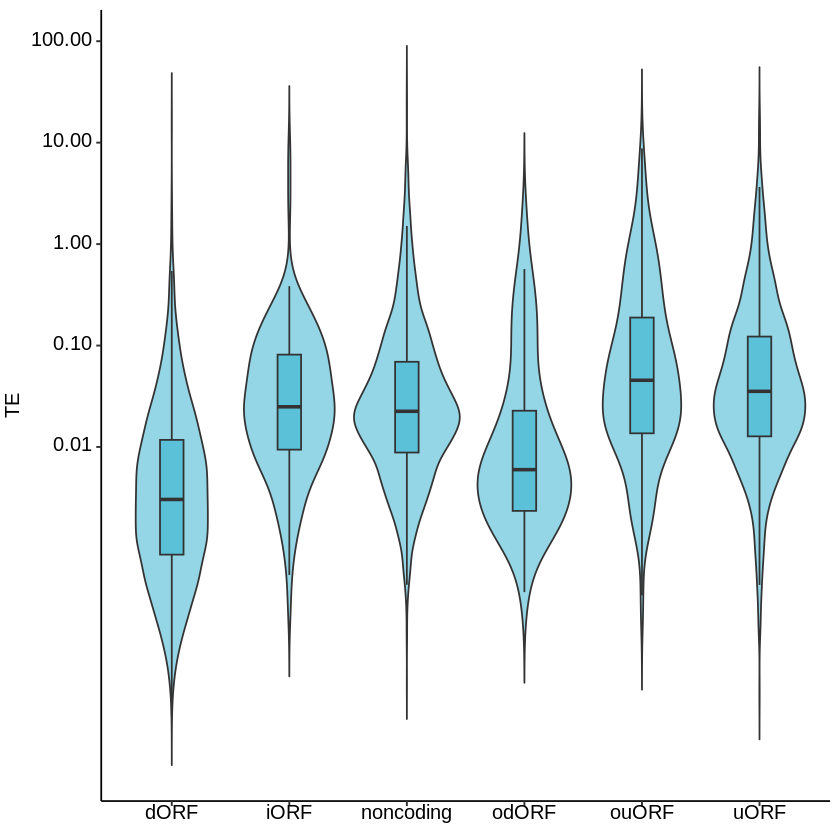

In [264]:
denovo_orfs <- denovo_orfs %>%
    mutate(TE = (RPF_RPKM+0.001)/(FL_TPM+0.001))
# 方案1：小提琴图 + 箱线图 + 柱状图（推荐）
p1 <- ggplot(denovo_orfs, aes(x = ORF_type, y = TE, fill = Type_1)) +
    # 小提琴图
    geom_violin(alpha = 0.6, trim = FALSE) +
    # 箱线图
    geom_boxplot(width = 0.2, alpha = 0.8, outlier.shape = NA) +
    # 主题和标签
    scale_fill_manual(values = type_colors) +
    labs(
        x=NULL,
        y = "TE"
    ) +
    guides(fill = "none")+
    theme_3()+
scale_y_log10(breaks = c(0.01, 0.1, 1, 10, 100),
        labels = c("0.01", "0.10", "1.00", "10.00", "100.00"))
p1
# compare(p1,type_pairs)

In [265]:
compare <- function(p,list){
  my_comparisons <- list
  res <- p+ stat_compare_means(comparisons = my_comparisons,label = "p.signif",
                               method = "wilcox.test",method.args = list(alternative = "two.sided"))
  res
}

In [266]:
type_names <- c("De novo human/hominoid genes","Canonical","lncRNA")
type_pairs <- combn(type_names, 2, simplify = FALSE)

In [267]:
type_names_1 <- c("human","hominoid","catarrhini","simiiformes","primates","primatomorpha","boreoeutheria",
            "placentalia","mammal","Canonical","lncRNA")
type_pairs_1 <- combn(type_names_1, 2, simplify = FALSE)

# 绘图设置

In [285]:
# 设置颜色（可根据需要调整）
type_colors <- c(
    "Canonical" = "#E64B35",
    "De novo human/hominoid genes" = "#4DBBD5",
    "De novo" = "#4DBBD5",
    "lncRNA" = "#00A087"
)

In [383]:
# 需要 rlang >= 0.4，支持 {{ }} 注入

violin_plot <- function(df, x, y, fill = x,
                        type_colors = NULL,
                        y_breaks = c(0.01, 0.1, 1, 10, 100),
                        y_label = "NC ratio") {
  ggplot(df, aes(x = {{x}}, y = {{y}}, fill = {{fill}})) +
    geom_violin(alpha = 0.6, trim = FALSE,scale = "width",width=0.6) +
    geom_boxplot(width = 0.2, alpha = 0.8, outlier.shape = NA) +
    { if (!is.null(type_colors)) scale_fill_manual(values = type_colors) else scale_fill_discrete() } +
    labs(x = NULL, y = y_label) +
    guides(fill = "none") +
    theme_3(rotate = T)
}
# scale_y_log10(breaks = y_breaks, labels = sprintf("%.2f", y_breaks))

In [390]:
out_name_1 <- function(x){
    paste0("../../figures/",x,"_compare.hominoid.pdf")
}
out_name_2 <- function(x){
    paste0("../../figures/",x,"_compare.all_denovo.pdf")
}

# CORR

In [268]:
cor(all$FL_TPM,all$A)
cor(all$FL_TPM,all$C)
cor(all$FL_TPM,all$N)

[1] 0.1535695

[1] 0.1452216

[1] 0.07542569

# GC含量

In [282]:
# ===== 1. 计算GC含量 =====
calculate_gc_content <- function(seq) {
    # 转换为大写
    seq_upper <- toupper(seq)
    # 计算G和C的数量
    gc_count <- str_count(seq_upper, "[GC]")
    # 计算总碱基数（排除N）
    total_count <- str_count(seq_upper, "[ATCG]")
    # 计算GC百分比
    gc_percent <- gc_count / total_count
    return(gc_percent)
}

# 为all数据框添加GC含量列
all <- all %>%
    mutate(GC_content = sapply(CDS_seq, calculate_gc_content))

[1] "GC含量统计："
# A tibble: 4 × 5
  Type_3                       mean_GC median_GC  sd_GC     n
  <fct>                          <dbl>     <dbl>  <dbl> <int>
1 Canonical                      0.532     0.528 0.0901  4506
2 De novo human/hominoid genes   0.529     0.534 0.141   1276
3 other                          0.509     0.5   0.143   5940
4 lncRNA                         0.472     0.470 0.131   2420


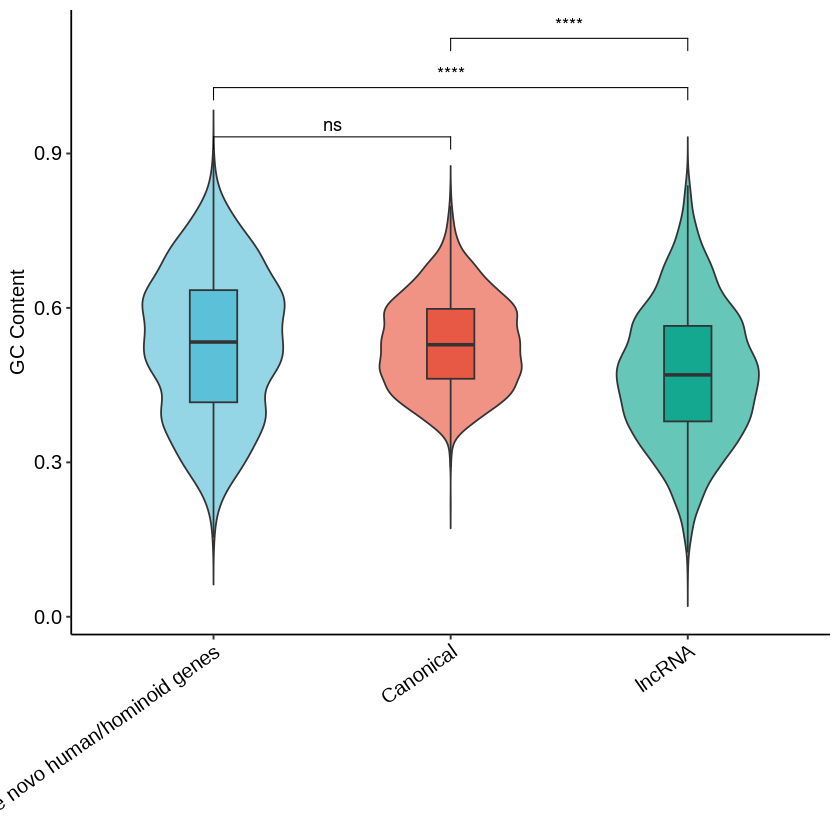

In [382]:
# ===== 2. 计算统计信息 =====
gc_stats <- all %>%
    group_by(Type_3) %>%
    summarise(
        mean_GC = mean(GC_content, na.rm = TRUE),
        median_GC = median(GC_content, na.rm = TRUE),
        sd_GC = sd(GC_content, na.rm = TRUE),
        n = n()
    ) %>%
    arrange(desc(mean_GC))

print("GC含量统计：")
print(gc_stats)

# ===== 3. 绘图：柱状图 + 小提琴图组合 =====

# 方案1：小提琴图 + 箱线图 + 柱状图（推荐）
p1 <- ggplot(all %>% filter(Type_3!="other"), aes(x = Type_3, y = GC_content, fill = Type_3)) +
    # 小提琴图
    geom_violin(alpha = 0.6, trim = FALSE,scale = "width",width=0.6) +
    # 箱线图
    geom_boxplot(width = 0.2, alpha = 0.8, outlier.shape = NA) +
    # 主题和标签
    scale_fill_manual(values = type_colors) +
    labs(
        x=NULL,
        y = "GC Content"
    ) +
    guides(fill = "none")+
    theme_3(rotate = T)
# p1
compare(p1,type_pairs)
ggsave(filename = "../../figures/GC_compare.homimoid.pdf",height = 6,width = 3)

Saving 6.67 x 6.67 in image


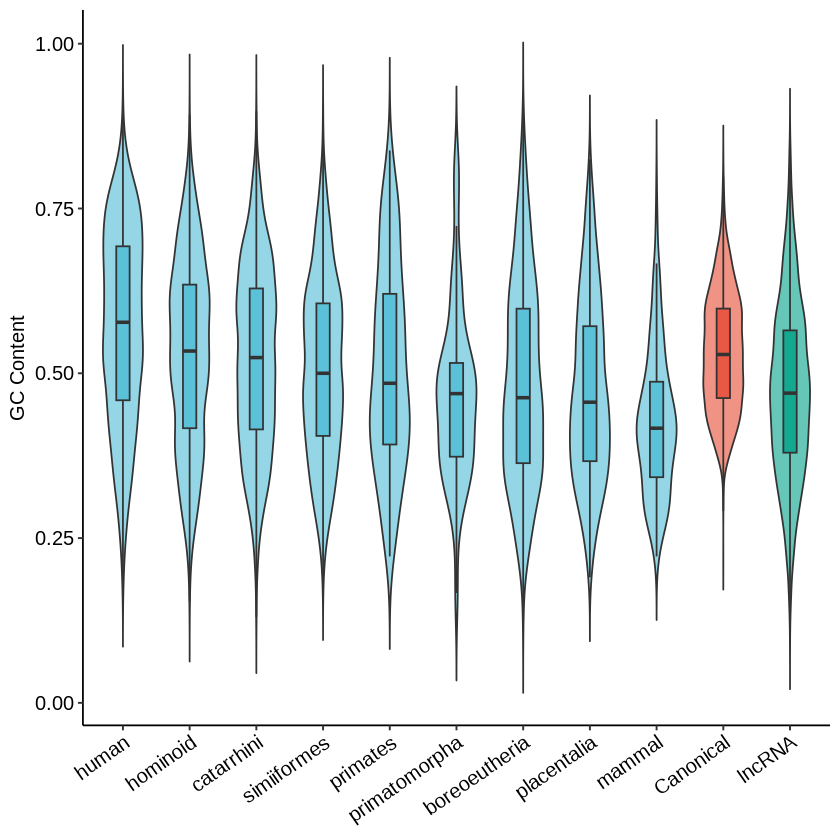

In [378]:
# 方案1：小提琴图 + 箱线图 + 柱状图（推荐）
p1 <- ggplot(all, aes(x = Type_2, y = GC_content, fill = Type_1)) +
    # 小提琴图
    geom_violin(alpha = 0.6, trim = FALSE,scale = "width",width=0.6) +
    # 箱线图
    geom_boxplot(width = 0.2, alpha = 0.8, outlier.shape = NA) +
    # 主题和标签
    scale_fill_manual(values = type_colors) +
    labs(
        x=NULL,
        y = "GC Content"
    ) +
    guides(fill = "none")+
    theme_3(rotate = T)
p1
ggsave(filename = "../../figures/GC_compare.all_denovo.pdf")

# 基因出核水平

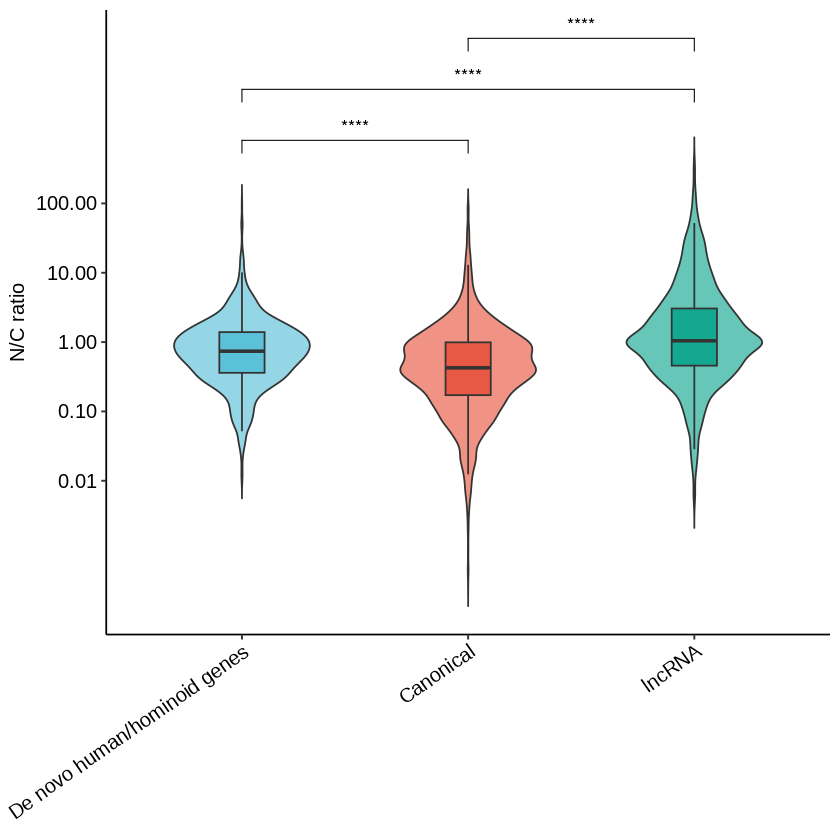

In [387]:
all <- all %>%
    mutate(NC_ratio = (N+0.001)/(C+0.001))
y_breaks = c(0.01, 0.1, 1, 10, 100)
p1 <- violin_plot(all %>% filter(Type_3!="other") , x = Type_3, y = NC_ratio, fill = Type_3, type_colors = type_colors,y_label = "N/C ratio")+
scale_y_log10(breaks = y_breaks, labels = sprintf("%.2f", y_breaks))
compare(p1, type_pairs)
ggsave(filename = out_name_1("NC_ratio"),height = 6,width = 3)

Saving 6.67 x 6.67 in image


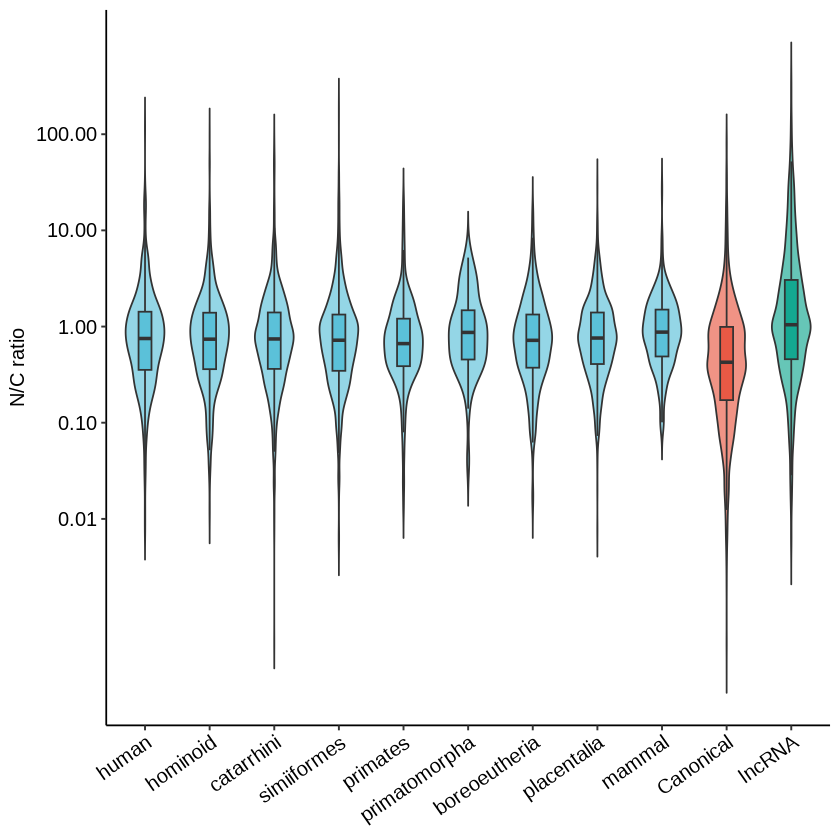

In [389]:
p1 <- violin_plot(all , x = Type_2, y = NC_ratio, fill = Type_1, type_colors = type_colors,y_label = "N/C ratio")+
scale_y_log10(breaks = y_breaks, labels = sprintf("%.2f", y_breaks))
p1
ggsave(filename = out_name_2("NC_ratio"))

# 翻译效率

In [299]:
fread_c("/home/user/data3/lit/project/sORFs/10-feature-egi/processed/feature_preprare/orf.rpf.psite.1.txt") -> ribo_res

In [300]:
head(ribo_res)

,ORF_id,RPF_reads,Psites_number,RPF_RPKM,Psites_RPKM,RPF_TPM,Psites_TPM,RPF_codon_coverage,Psites_codon_coverage
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,PB.41013.1:chr6:+|1|330:5:44|noncoding|GTG,3,0,0.00550741,0.00000000,0.000460347,0.000000000,0.2500000,0.0000000
2,PB.41013.1:chr6:+|2|330:16:79|noncoding|CTG,5,0,0.00550741,0.00000000,0.000460347,0.000000000,0.2500000,0.0000000
3,PB.41013.1:chr6:+|5|330:53:263|noncoding|TTG,7159,2770,2.28566000,1.26053000,0.191051000,0.142754000,103.7540000,40.1449000
4,PB.41013.1:chr6:+|9|330:109:166|noncoding|ATG,0,0,0.00000000,0.00000000,0.000000000,0.000000000,0.0000000,0.0000000
5,PB.41013.1:chr6:+|10|330:111:219|noncoding|GTG,3,3,0.00188826,0.00269138,0.000157833,0.000304797,0.0857143,0.0857143
6,PB.41013.1:chr6:+|14|330:202:253|noncoding|CTG,7105,183,9.78254000,0.35913100,0.817691000,0.040671400,444.0620000,11.4375000


In [301]:
merge(ribo_res[,c("ORF_id","RPF_TPM")],all,by="ORF_id") -> all_1

In [302]:
nrow(all)
nrow(all_1)

[1] 14142

[1] 14142

In [303]:
cor(all_1$RPF_TPM,all_1$RPF_RPKM)
cor(all_1$RPF_RPKM,all_1$RPF_codon_coverage)

[1] 1

[1] 1

In [351]:
stat6 <- function(x) {
  c(min = min(x, na.rm = TRUE),
    q1 = quantile(x, 0.25, na.rm = TRUE),
    median = median(x, na.rm = TRUE),
    mean = mean(x, na.rm = TRUE),
    q3 = quantile(x, 0.75, na.rm = TRUE),
    max = max(x, na.rm = TRUE))
}

# 一列
all %>%
  group_by(Type_1) %>%
  reframe(as.data.frame(t(stat6(FL_TPM))))
all %>%
  group_by(Type_1) %>%
  reframe(as.data.frame(t(stat6(FL))))
all %>%
  group_by(Type_1) %>%
  reframe(as.data.frame(t(stat6(A))))
all %>%
  group_by(Type_1) %>%
  reframe(as.data.frame(t(stat6(RPF_reads))))

Type_1,min,q1.25%,median,mean,q3.75%,max
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
De novo,0.273352,0.410029,1.093410,11.529443,5.193697,1711.5964
Canonical,0.273352,0.410029,0.956734,13.792470,3.690258,3074.5320
lncRNA,0.273352,0.273352,0.410029,1.523319,0.820057,480.6903


Type_1,min,q1.25%,median,mean,q3.75%,max
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
De novo,2,3,8,84.35588,38,12523
Canonical,2,3,7,100.91345,27,22495
lncRNA,2,2,3,11.14545,6,3517


Type_1,min,q1.25%,median,mean,q3.75%,max
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
De novo,0,1.1054052,2.3271161,4.1731094,4.2773315,581.2968
Canonical,0,1.2362376,2.3312177,7.5087584,4.6893617,1030.5642
lncRNA,0,0.1305252,0.3498147,0.9680441,0.7622747,323.1293


Type_1,min,q1.25%,median,mean,q3.75%,max
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
De novo,1,11,28,223.24695,96.00,89950
Canonical,0,563,1796,7511.88904,5755.75,3019474
lncRNA,0,0,0,33.58347,6.00,10814


In [311]:
all %>%
  group_by(Type_1) %>%
  summarise(
    min   = min(FL, na.rm = TRUE),
    q1    = quantile(FL, 0.25, na.rm = TRUE),
    median= median(FL, na.rm = TRUE),
    mean  = mean(FL, na.rm = TRUE),
    q3    = quantile(FL, 0.75, na.rm = TRUE),
    max   = max(FL, na.rm = TRUE),
    .groups = "drop"
  )


Type_1,min,q1,median,mean,q3,max
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
De novo,2,3,8,84.35588,38,12523
Canonical,2,3,7,100.91345,27,22495
lncRNA,2,2,3,11.14545,6,3517


In [310]:
all %>% filter(Type_1=="Canonical") -> tmp
nrow(tmp)
summary(tmp$FL_TPM)

[1] 4506

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
   0.2734    0.4100    0.9567   13.7925    3.6903 3074.5320 

In [325]:
# filter(lnc_orfs,A==0)

In [341]:
# all <- all %>%
#     mutate(TE = (RPF_codon_coverage+0.000001)/(FL_TPM+0.000001))
# y_breaks = c(0.01, 0.1, 1, 10, 100)
# p1 <- violin_plot(all %>% filter(Type_3!="other") , x = Type_3, y = TE, fill = Type_3, type_colors = type_colors,y_label = "TE")+
# scale_y_log10(breaks = y_breaks, labels = sprintf("%.2f", y_breaks))
# compare(p1, type_pairs)

# p1 <- violin_plot(all , x = Type_2, y = TE, fill = Type_1, type_colors = type_colors,y_label = "TE")+
# scale_y_log10(breaks = y_breaks, labels = sprintf("%.2f", y_breaks))
# p1

In [333]:
# all_1 <- all_1 %>%
#     mutate(TE = (RPF_TPM+0.001)/(FL_TPM+0.001))
# y_breaks = c(0.01, 0.1, 1, 10, 100)
# p1 <- violin_plot(all_1 %>% filter(Type_3!="other") , x = Type_3, y = TE, fill = Type_3, type_colors = type_colors)+
# scale_y_log10(breaks = y_breaks, labels = sprintf("%.2f", y_breaks))
# compare(p1, type_pairs)

# p1 <- violin_plot(all_1 , x = Type_2, y = TE, fill = Type_1, type_colors = type_colors)+
# scale_y_log10(breaks = y_breaks, labels = sprintf("%.2f", y_breaks))
# p1

## 作图

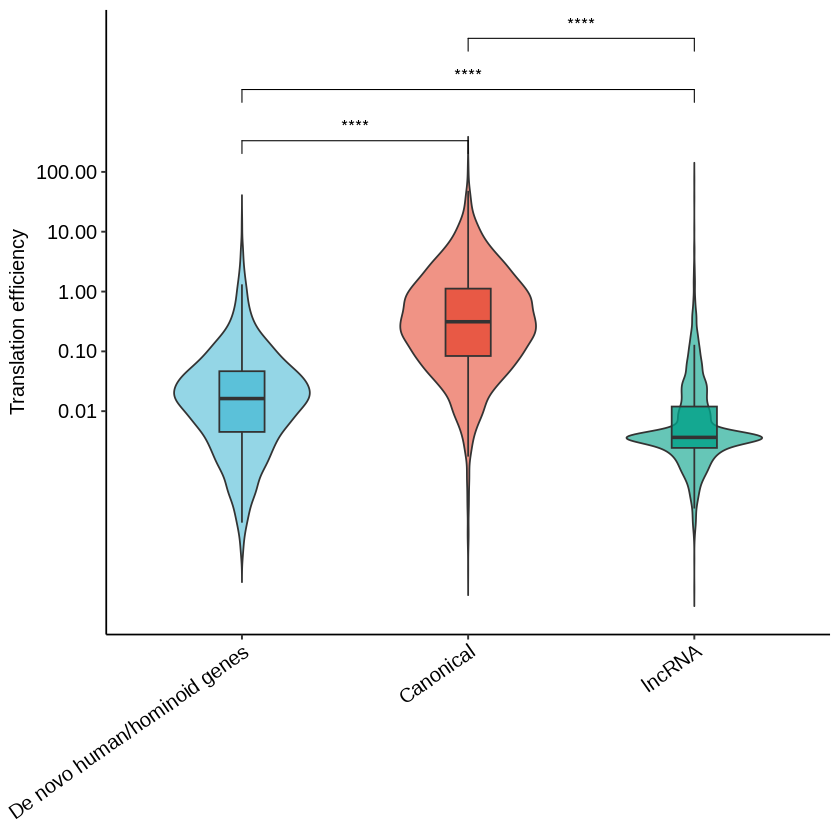

Saving 6.67 x 6.67 in image


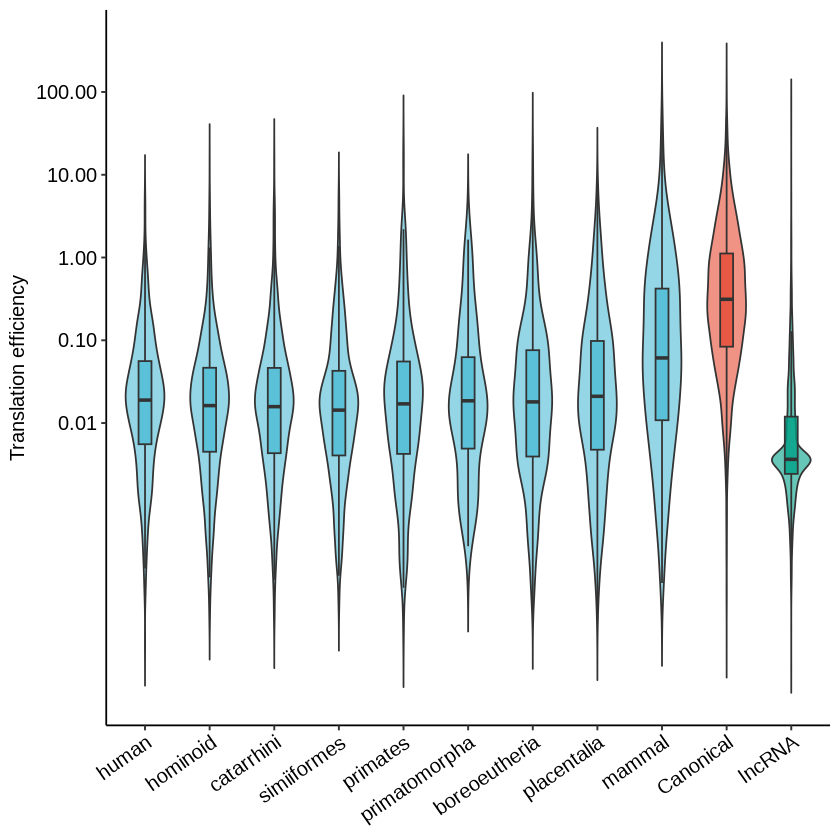

In [392]:
all <- all %>%
    mutate(TE = (RPF_RPKM+0.001)/(FL_TPM+0.001))
y_breaks = c(0.01, 0.1, 1, 10, 100)
p1 <- violin_plot(all %>% filter(Type_3!="other") , x = Type_3, y = TE, fill = Type_3, type_colors = type_colors,y_label = "Translation efficiency")+
scale_y_log10(breaks = y_breaks, labels = sprintf("%.2f", y_breaks))
compare(p1, type_pairs)
ggsave(filename = out_name_1("TE"),height = 6,width = 3)

p1 <- violin_plot(all , x = Type_2, y = TE, fill = Type_1, type_colors = type_colors,y_label = "Translation efficiency")+
scale_y_log10(breaks = y_breaks, labels = sprintf("%.2f", y_breaks))
p1
ggsave(filename = out_name_2("TE"))

Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 1299 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 1299 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


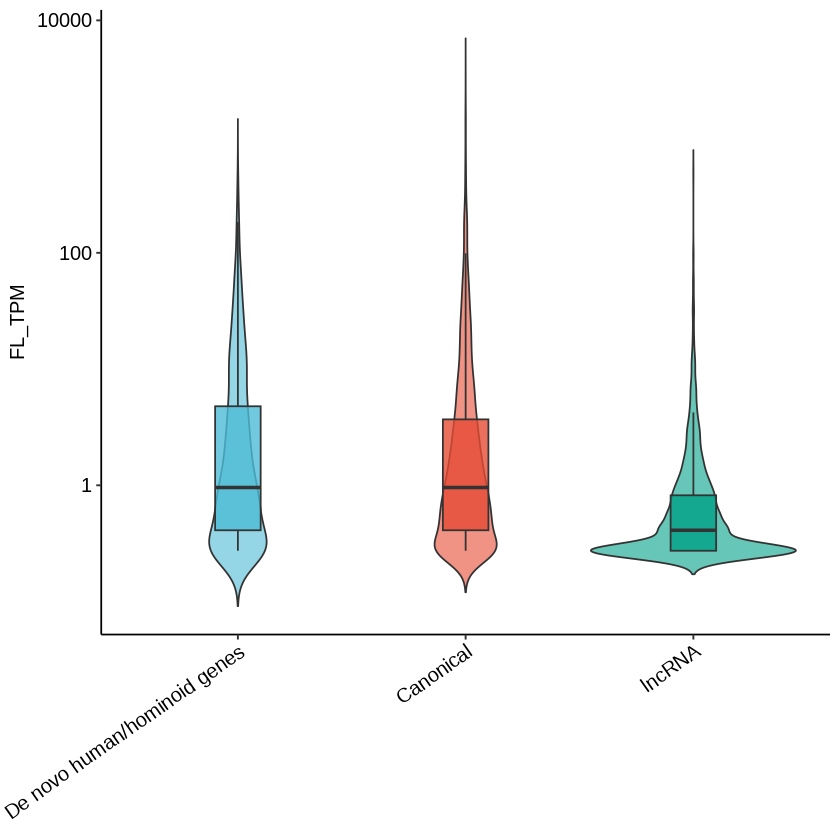

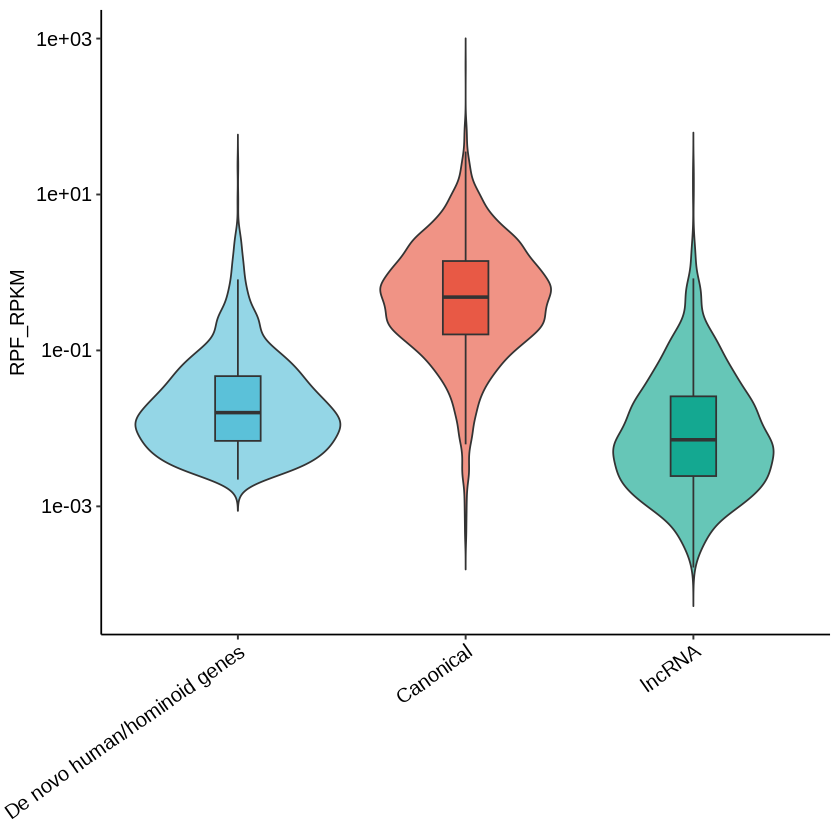

In [360]:
# 查看表达量和翻译水平
violin_plot(all %>% filter(Type_3!="other") , x = Type_3, y = FL_TPM, fill = Type_3, type_colors = type_colors,y_label = "FL_TPM")+
scale_y_log10()

violin_plot(all %>% filter(Type_3!="other") , x = Type_3, y = RPF_RPKM, fill = Type_3, type_colors = type_colors,y_label = "RPF_RPKM")+
scale_y_log10()

# C端疏水性

In [342]:
all %>%
  group_by(Type_1) %>%
  reframe(as.data.frame(t(stat6(ORF_length))))

Type_1,min,q1.25%,median,mean,q3.75%,max
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
De novo,6,18,30,39.17808,52,150
Canonical,12,61,91,91.04239,121,150
lncRNA,6,11,19,26.54215,33,147


In [372]:
library(Peptides)
all <- all %>%
      mutate(Last15A = substr(ORF_seq,start = ORF_length-14, stop=ORF_length)) %>% 
mutate(Hydrophobicity_full = hydrophobicity(ORF_seq, scale = "Miyazawa")) %>% 
mutate(Hydrophobicity_Last15A = hydrophobicity(Last15A, scale = "Miyazawa")) -> all
head(all[,c("Last15A","Hydrophobicity_full","Hydrophobicity_Last15A")])

,Last15A,Hydrophobicity_full,Hydrophobicity_Last15A
,<chr>,<dbl>,<dbl>
1,ANEDPEPEQDYGAGG,5.477683,4.229333
2,NPYVLGIRDTDSAQV,5.502590,5.310000
3,IRSFVDKVGESNNMV,6.545405,5.610000
4,LFFDKALLAIGNKLL,6.654286,6.505333
5,MILFFDKALLAIGNE,6.581000,6.608000
6,IRSFVDKVGESNNMV,6.567029,5.610000


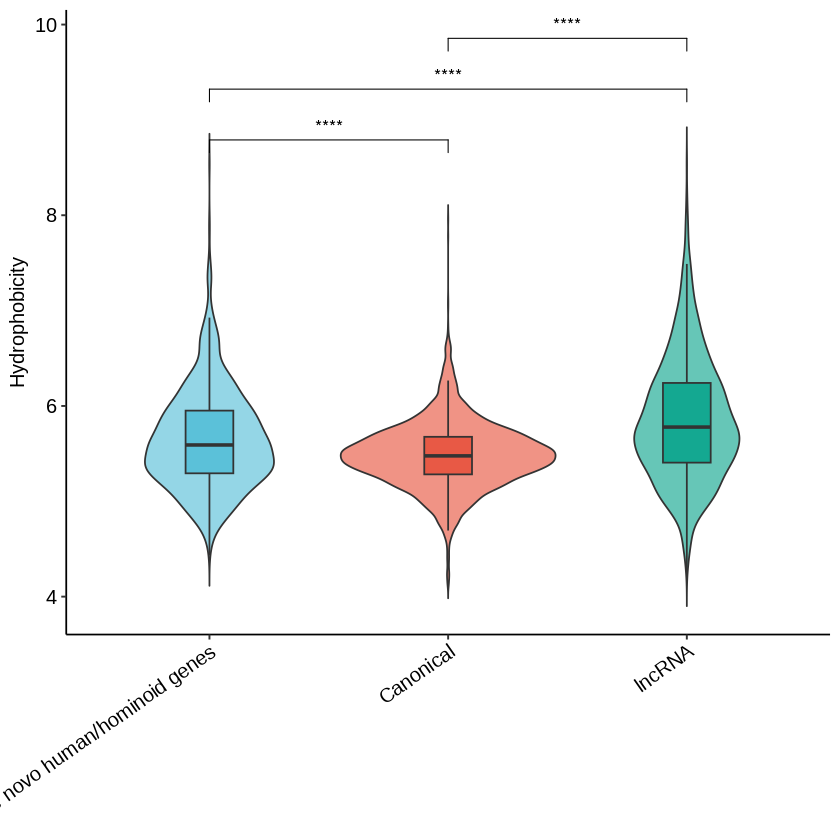

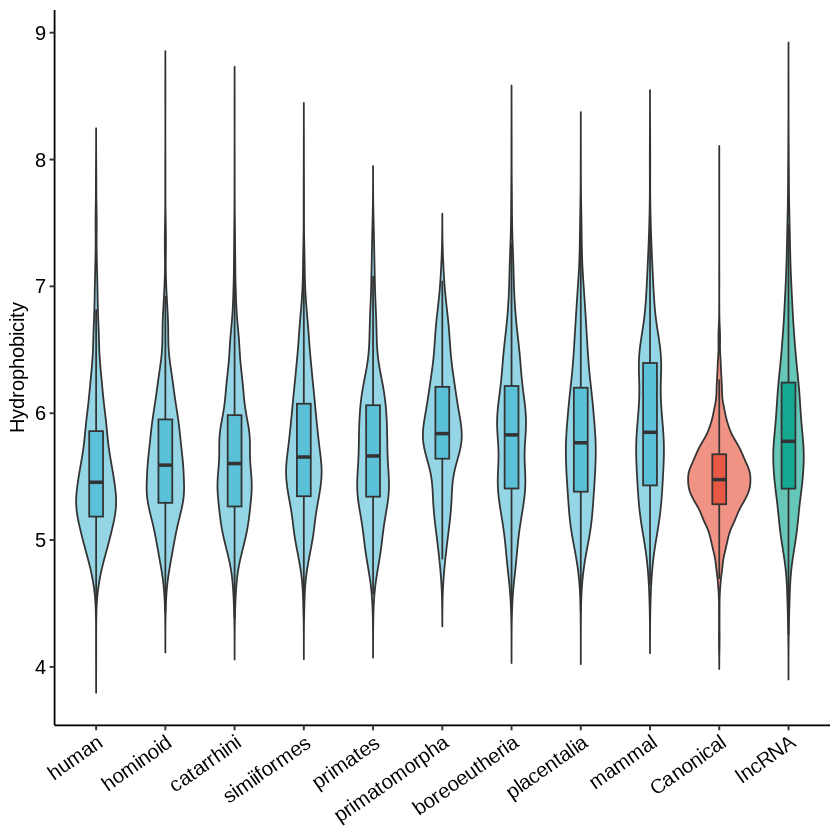

In [346]:
p1 <- violin_plot(all %>% filter(Type_3!="other") , x = Type_3, y = Hydrophobicity_full, fill = Type_3, type_colors = type_colors,y_label = "Hydrophobicity")
compare(p1, type_pairs)

p1 <- violin_plot(all , x = Type_2, y = Hydrophobicity_full, fill = Type_1, type_colors = type_colors,y_label = "Hydrophobicity")
p1

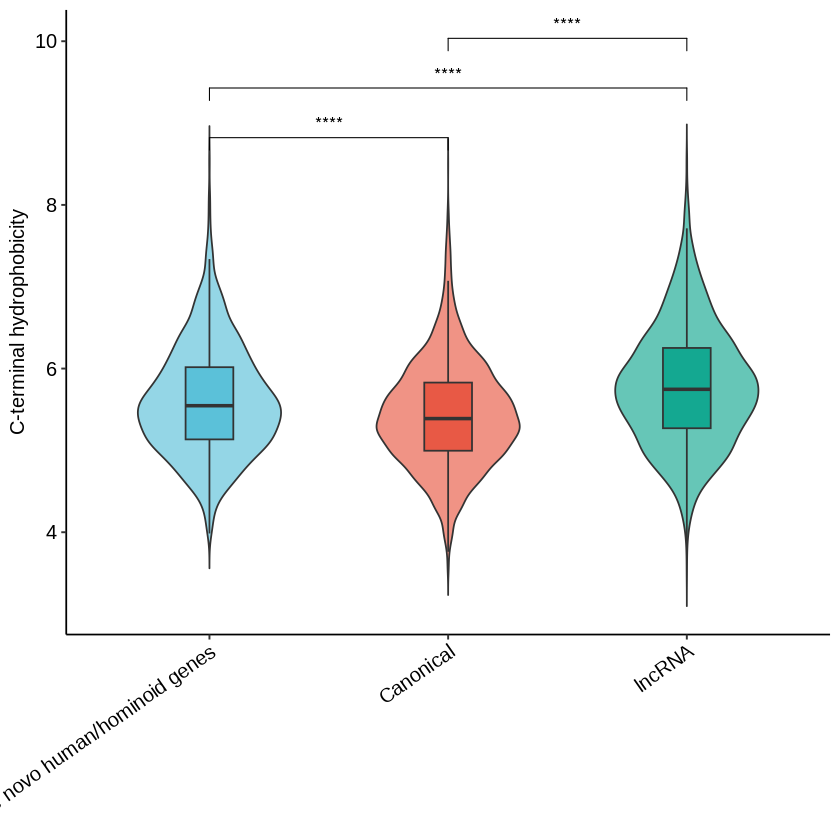

Saving 6.67 x 6.67 in image


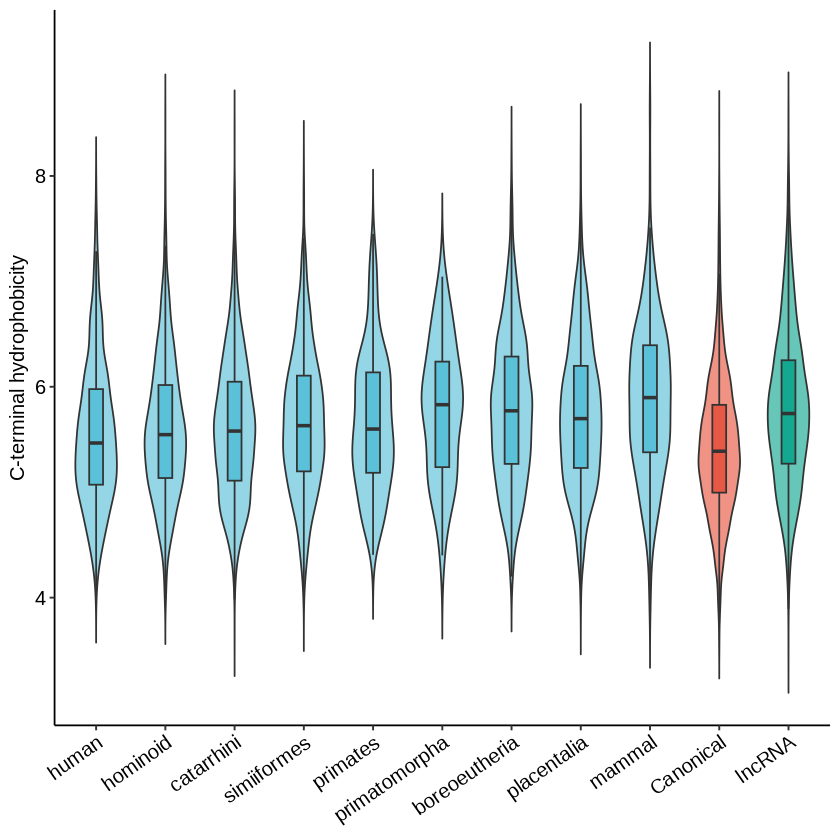

In [393]:
p1 <- violin_plot(all %>% filter(Type_3!="other") , x = Type_3, y = Hydrophobicity_Last15A, fill = Type_3, type_colors = type_colors,y_label = "C-terminal hydrophobicity")
compare(p1, type_pairs)
ggsave(filename = out_name_1("C_terminal_hydrophobicity"),height = 6,width = 3)
p1 <- violin_plot(all , x = Type_2, y = Hydrophobicity_Last15A, fill = Type_1, type_colors = type_colors,y_label = "C-terminal hydrophobicity")
p1
ggsave(filename = out_name_2("C_terminal_hydrophobicity"))

# 内在结构无序性

In [368]:
fread_c("../../processed/seve_list_compare/ISD_avg/100_denovo_genes.aa_no_C.ISD_avg.txt") -> tmp_1
fread_c("../../processed/seve_list_compare/ISD_avg/lncRNA_ORFs.gt30.shuffle.aa_no_C.ISD_avg.txt") -> tmp_2
fread_c("../../processed/seve_list_compare/ISD_avg/pc_ORFs.shuffle.aa_no_C.ISD_avg.txt") -> tmp_3
rbind(tmp_1,tmp_2,tmp_3) -> ISD_res
colnames(ISD_res) <- c("ORF_id","Avg_ISD","Protein_length")
head(ISD_res,1)

,ORF_id,Avg_ISD,Protein_length
,<chr>,<dbl>,<int>
1,PB.1001.3:chr1:-|9|2745:169:253|iORF|AG,0.9591,33


In [369]:
merge(all,ISD_res,by="ORF_id") %>% count(Type_1)
merge(all,ISD_res,by="ORF_id")  -> all_with_ISD

Type_1,n
<fct>,<int>
De novo,5402
Canonical,4490
lncRNA,1796


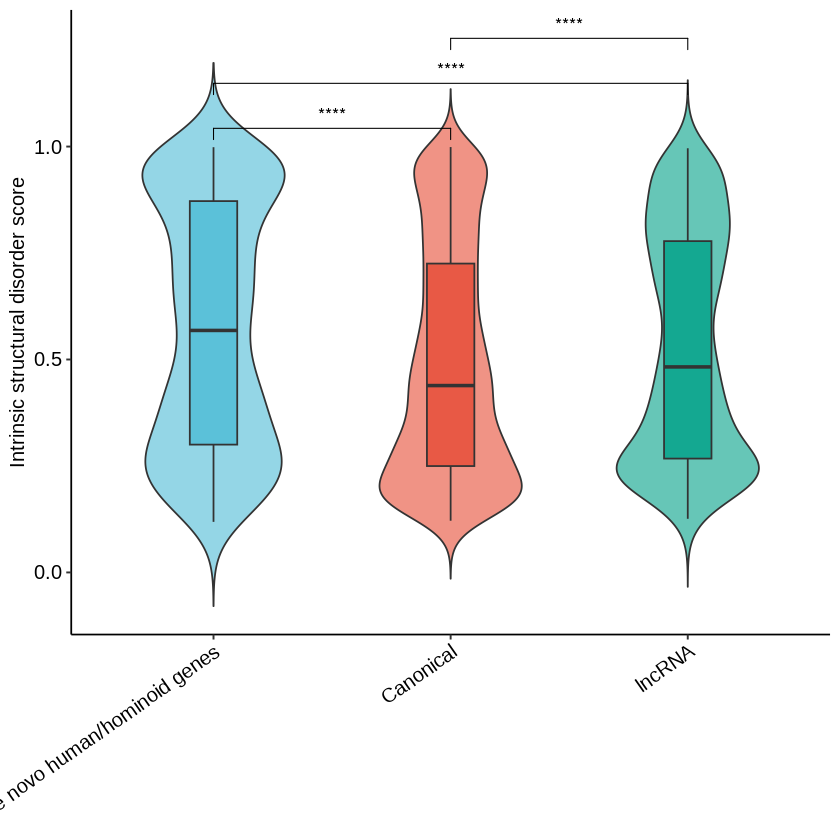

Saving 6.67 x 6.67 in image


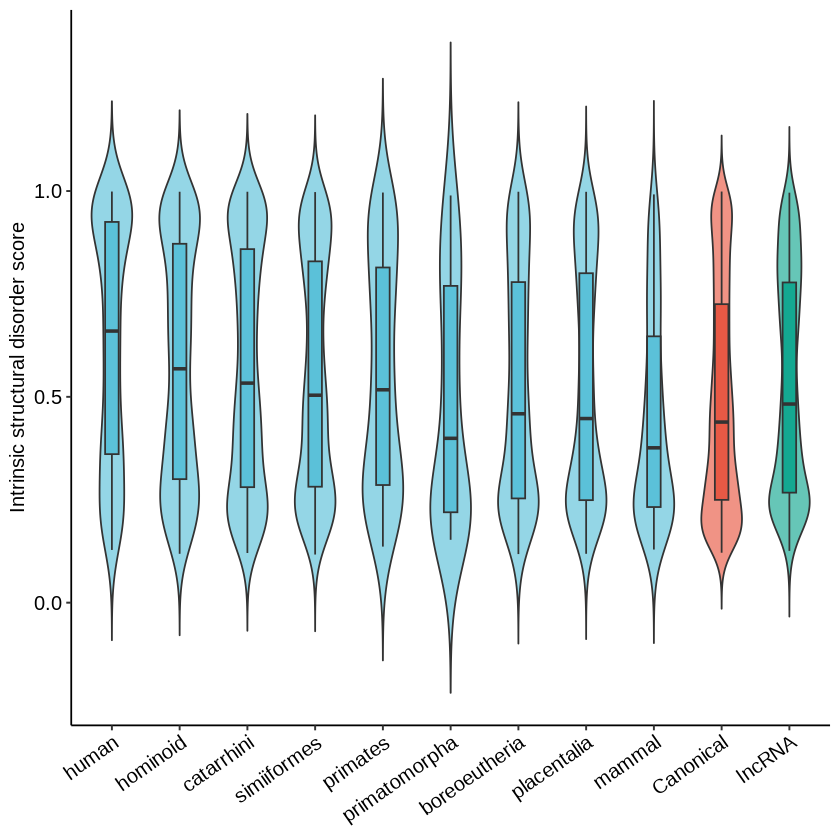

In [394]:
p1 <- violin_plot(all_with_ISD %>% filter(Type_3!="other") , x = Type_3, y = Avg_ISD, fill = Type_3, type_colors = type_colors,y_label = "Intrinsic structural disorder score")
compare(p1, type_pairs)
ggsave(filename = out_name_1("ISD"),height = 6,width = 3)

p1 <- violin_plot(all_with_ISD , x = Type_2, y = Avg_ISD, fill = Type_1, type_colors = type_colors,y_label = "Intrinsic structural disorder score")
p1
ggsave(filename = out_name_2("ISD"))